CSC221 Group Project Part 1

Student: Nicolas Lammons
Partner: Andrew Kostopoulos

This program scrapes a table of U.S. state populations from Wikipedia and saves it to a CSV file.

Import libraries

In [1]:
# import needed libraries
import pandas as pd
import requests
from io import StringIO

Get the webpage

In [2]:
# wikipedia page link
url = "https://en.wikipedia.org/wiki/List_of_U.S._states_and_territories_by_population"

# request page with header to avoid 403 error
headers = {"User-Agent": "Mozilla/5.0"}
r = requests.get(url, headers=headers)

Read tables from the webpage

In [3]:
# read tables from html text
tables = pd.read_html(StringIO(r.text))

print("Number of tables found:", len(tables))


Number of tables found: 6


Store the main table

In [4]:
# select the main table (adjust index if needed)
df = tables[0]

Show first 10 rows

In [5]:
# display first 10 rows
df.head(10)

State or territory Census population[8][9][a]               House seats[b]  \
  State or territory        July 1, 2025 (est.) April 1, 2020          Seats   
0         California                 39355309.0      39538223             52   
1              Texas                 31709821.0      29145505             38   
2            Florida                 23462518.0      21538187             28   
3           New York                 20002427.0      20201249             26   
4       Pennsylvania                 13059432.0      13002700             17   
5           Illinois                 12719141.0      12812508             17   
6               Ohio                 11900510.0      11799448             15   
7            Georgia                 11302748.0      10711908             14   
8     North Carolina                 11197968.0      10439388             14   
9           Michigan                 10127884.0      10077331             13   

          Pop. per elec. vote (2020)[c] Pop. per seat (2020)[a] % US (2020)  \
        % Pop. per elec. vote (2020)[c] Pop. per seat (2020)[a] % US (2020)   
0  11.95%                        732189                  760350     11.800%   
1   8.74%                        728638                  766987      8.698%   
2   6.44%                        717940                  769221      6.428%   
3   5.98%                        721473                  776971      6.029%   
4   3.91%                        684353                  764865      3.881%   
5   3.91%                        674343                  753677      3.824%   
6   3.45%                        694085                  786630      3.521%   
7   3.22%                        669494                  765136      3.197%   
8   3.22%                        652462                  745671      3.116%   
9   2.99%                        671822                  775179      3.008%   

  % EC (2020)  
  % EC (2020)  
0      10.04%  
1       7.43%  
2       5.58%  
3       5.20%  
4       3.53%  
5       3.53%  
6       3.16%  
7       2.97%  
8       2.97%  
9       2.79%

Save data to CSV

In [6]:
# save to csv file
df.to_csv("CSC221-webscrape-data.csv", index=False)

print("file saved")

file saved


Check data info

In [7]:
# show size and columns
print(df.shape)
print(df.columns)

(60, 9)
MultiIndex([(           'State or territory',            'State or territory'),
            (   'Census population[8][9][a]',           'July 1, 2025 (est.)'),
            (   'Census population[8][9][a]',                 'April 1, 2020'),
            (               'House seats[b]',                         'Seats'),
            (               'House seats[b]',                             '%'),
            ('Pop. per elec. vote (2020)[c]', 'Pop. per elec. vote (2020)[c]'),
            (      'Pop. per seat (2020)[a]',       'Pop. per seat (2020)[a]'),
            (                  '% US (2020)',                   '% US (2020)'),
            (                  '% EC (2020)',                   '% EC (2020)')],
           )


# Here is Andrew's code

Here is my code for Part II of the Final Project. Here, I construct a pie chart showing the population of the *n* most populous states, as compared to the rest of the country. I have this set to 10, but it can theoretically be any number.

In development, I initially had it list all 50 states (plus Puerto Rico and Washington, D.C.), but the titles would overlap to the point of indistinction and the wedges would be too tiny to distinguish.

([<matplotlib.patches.Wedge at 0x1e42582da90>,
 [Text(1.0301038386912216, 0.3858575922715658, 'California'),
  Text(0.5891545338367422, 0.928922459228762, 'Texas'),
  Text(0.06899626341519483, 1.0978340109664764, 'Florida'),
  Text(-0.3596343220408501, 1.0395494958924363, 'New York'),
  Text(-0.6517458378403321, 0.8861305563277929, 'Pennsylvania'),
  Text(-0.8399925860857411, 0.710220004872426, 'Illinois'),
  Text(-0.9768740466508457, 0.5056847802534715, 'Ohio'),
  Text(-1.0612079299943311, 0.28954745607092974, 'Georgia'),
  Text(-1.0979236416138118, 0.06755499378629454, 'North Carolina'),
  Text(-1.0903204791603847, -0.1456064995921181, 'Michigan'),
  Text(0.12348466064950588, -1.093046905939666, 'Other States/Entities')])

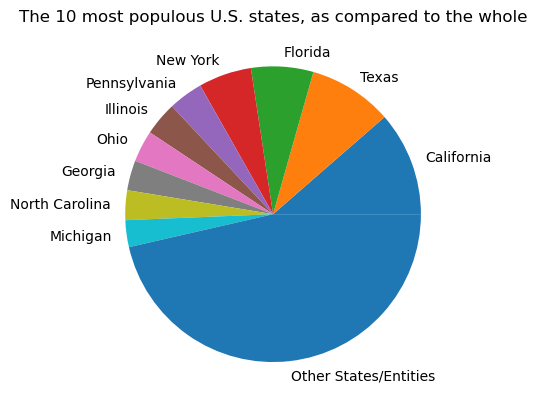

In [8]:
import matplotlib.pyplot as plt

# These two variables are what the pie chart shall look for.
pie_chart_variables = [
    ('State or territory', 'State or territory'),
    ('Census population[8][9][a]', 'July 1, 2025 (est.)')
]

# These will not be added to the pie chart on account of their populations for 2025
# either showing up as "N/A", or being the sum of other entities' populations.
pie_chart_exemptions = [
    'Guam[11]',
    'U.S. Virgin Islands[12]',
    'American Samoa[13]',
    'Northern Mariana Islands[14]',
    'Contiguous United States',
    'The 50 states',
    'The 50 states and D.C.',
    'Total US and territories'
]

# Grabs the initial values from the `DataFrame` provided.
pie_chart_data_preliminary = [
    df[('State or territory', 'State or territory')].values.tolist(),
    df[('Census population[8][9][a]', 'July 1, 2025 (est.)')].values.tolist()
]

# Thins the lists down to get rid of the values listed in `pie_chart_exemptions`.
pie_chart_data_intermediate = [[], []]
for x in range(df.shape[0]):
    if (not (pie_chart_data_preliminary[0][x] in pie_chart_exemptions)):
        pie_chart_data_intermediate[0].append(pie_chart_data_preliminary[0][x])
        pie_chart_data_intermediate[1].append(pie_chart_data_preliminary[1][x])

# Bundles all the states' populations below the specified cutoff number into a
# single "Other States/Entities" wedge.
most_populous_states = 10
pie_chart_data_final = [[], []]
for x in range(len(pie_chart_data_intermediate[0])):
    if x < most_populous_states:
        # Documents the 10 most-populous states/entities as per normal
        pie_chart_data_final[0].append(pie_chart_data_intermediate[0][x])
        pie_chart_data_final[1].append(pie_chart_data_intermediate[1][x])
    else:
        # Adds all other states' populations to "Other States/Entities" wedge
        if not len(pie_chart_data_final[1]) > most_populous_states:
            pie_chart_data_final[0].append('Other States/Entities')
            pie_chart_data_final[1].append(0)
        pie_chart_data_final[1][-1] += pie_chart_data_intermediate[1][x]

# Plots the pie chart.
fig, ax = plt.subplots()
plt.title('The ' + str(most_populous_states) + ' most populous U.S. states, as compared to the whole')
ax.pie(
    pie_chart_data_final[1],
    labels = pie_chart_data_final[0]
)
